In [7]:
%pip install PyWavelets antropy --quiet

Note: you may need to restart the kernel to use updated packages.


# Модифицированный пайплайн c RandomForestClassifier для дыхания, SpO2 и PPG (стадии N1 и N2 объединили в light sleep)

In [8]:
import numpy as np
import pandas as pd
import mne
from scipy import signal
from scipy.signal import find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [9]:
import antropy as ant

In [10]:
# ------------------------------------------------------------
# 1. Функции загрузки, предобработки и извлечения признаков
# ------------------------------------------------------------

def load_edf_signals(edf_path, channels):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.pick_channels(channels)
    sfreq = raw.info['sfreq']
    signals = {ch: raw[ch][0].flatten() for ch in channels}
    return raw, signals, sfreq

def preprocess_signal(data, sfreq, lowcut=0.1, highcut=10, order=4):
    nyquist = 0.5 * sfreq
    low = lowcut / nyquist
    high = highcut / nyquist
    if low <= 0 or low >= high:
        b, a = signal.butter(order, high, btype='low')
    else:
        b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, data)

def resample_signal(data, orig_sfreq, target_sfreq):
    if orig_sfreq == target_sfreq:
        return data
    num_samples = int(len(data) * target_sfreq / orig_sfreq)
    return signal.resample(data, num_samples)

def detect_resp_rate(resp_signal, sfreq):
    min_distance = int(2 * sfreq)
    peaks, _ = find_peaks(resp_signal, distance=min_distance, prominence=np.std(resp_signal)*0.2)
    if len(peaks) < 2:
        return np.nan
    intervals = np.diff(peaks) / sfreq
    return 60 / np.mean(intervals)

def detect_heart_rate(ppg_signal, sfreq):
    low = 0.5 / (sfreq/2)
    high = 5.0 / (sfreq/2)
    b, a = signal.butter(2, [low, high], btype='band')
    filtered_ppg = signal.filtfilt(b, a, ppg_signal)
    min_distance = int(0.5 * sfreq)
    peaks, _ = find_peaks(filtered_ppg, distance=min_distance, prominence=np.std(filtered_ppg)*0.5)
    if len(peaks) < 2:
        return np.nan, np.nan, np.nan, np.nan
    rr_intervals = np.diff(peaks) / sfreq
    heart_rate = 60 / np.mean(rr_intervals)
    rmssd = np.sqrt(np.mean(np.diff(rr_intervals)**2))
    sdnn = np.std(rr_intervals)
    nn50 = np.sum(np.abs(np.diff(rr_intervals)) > 0.05)
    pnn50 = nn50 / len(rr_intervals) * 100
    return heart_rate, rmssd, sdnn, pnn50

def extract_features_from_window(window_signals, sfreq, channel_names):
    features = {}
    for ch in channel_names:
        data = window_signals[ch]
        if ch.startswith('RESP Breath'):
            features[f'{ch}_mean'] = np.mean(data)
            features[f'{ch}_std'] = np.std(data)
            features[f'{ch}_min'] = np.min(data)
            features[f'{ch}_max'] = np.max(data)
            features[f'{ch}_p10'] = np.percentile(data, 10)
            features[f'{ch}_p90'] = np.percentile(data, 90)
            features[f'{ch}_slope'] = (data[-1] - data[0]) / len(data)
            resp_rate = detect_resp_rate(data, sfreq)
            features[f'{ch}_resp_rate'] = resp_rate if not np.isnan(resp_rate) else 0
            entropy = ant.spectral_entropy(data, sfreq, method='welch')
            features[f'{ch}_entropy'] = entropy
        elif ch == 'SAO2 SpO2':
            features[f'{ch}_mean'] = np.mean(data)
            features[f'{ch}_std'] = np.std(data)
            features[f'{ch}_min'] = np.min(data)
            features[f'{ch}_desat_count_3pct'] = np.sum(np.diff(data) <= -3)
        elif ch == 'PPG':
            features[f'{ch}_mean'] = np.mean(data)
            features[f'{ch}_std'] = np.std(data)
            hr, rmssd, sdnn, pnn50 = detect_heart_rate(data, sfreq)
            features[f'{ch}_heart_rate'] = hr if not np.isnan(hr) else 0
            features[f'{ch}_rmssd'] = rmssd if not np.isnan(rmssd) else 0
            features[f'{ch}_sdnn'] = sdnn if not np.isnan(sdnn) else 0
            features[f'{ch}_pnn50'] = pnn50 if not np.isnan(pnn50) else 0
    return features

def extract_epochs_dataset(raw, signals, sfreq, epoch_duration=30, channel_names=None):
    if channel_names is None:
        channel_names = list(signals.keys())
    n_samples = len(signals[channel_names[0]])
    duration_sec = n_samples / sfreq
    n_epochs = int(duration_sec // epoch_duration)
    
    annotations = raw.annotations
    
    # Словарь для преобразования строк описания в номера стадий
    stage_mapping = {
        'Sleep stage W(eventUnknown)': 0,
        'Sleep stage 1(eventUnknown)': 1,
        'Sleep stage 2(eventUnknown)': 1,   # N2 → Light
        'Sleep stage 3(eventUnknown)': 2,
        'Sleep stage R(eventUnknown)': 3,
    }
    
    # Инициализируем массив меток для эпох значением None
    y_epochs = [None] * n_epochs
    
    # Проходим по всем аннотациям
    for ann in annotations:
        description = ann['description']
        # Если это не фаза сна, пропускаем
        if description not in stage_mapping:
            continue
        stage = stage_mapping[description]
        onset = ann['onset']
        duration = ann['duration']
        # Определяем, какие эпохи перекрываются с этой аннотацией
        # Эпоха i начинается в i*epoch_duration, заканчивается в (i+1)*epoch_duration
        start_epoch = int(onset // epoch_duration)
        end_epoch = int((onset + duration) // epoch_duration) + 1
        # Ограничиваем диапазон
        start_epoch = max(0, start_epoch)
        end_epoch = min(n_epochs, end_epoch)
        for i in range(start_epoch, end_epoch):
            if y_epochs[i] is None:
                y_epochs[i] = stage
            # Если уже есть метка, можно оставить первую (или реализовать большинство, но это редко нужно)
    
    # Собираем индексы эпох, у которых есть метка
    valid_epochs = [i for i, label in enumerate(y_epochs) if label is not None]
    if len(valid_epochs) == 0:
        raise ValueError("Не найдено эпох, соответствующих аннотациям фаз сна. Проверьте временные метки аннотаций.")
    
    # Далее извлечение признаков как в исходном коде...
    X_list = []
    y_list = []
    for i in tqdm(valid_epochs, desc="Извлечение признаков по эпохам"):
        start_sample = int(i * epoch_duration * sfreq)
        end_sample = int((i+1) * epoch_duration * sfreq)
        window_signals = {ch: signals[ch][start_sample:end_sample] for ch in channel_names}
        feat_dict = extract_features_from_window(window_signals, sfreq, channel_names)
        X_list.append(feat_dict)
        y_list.append(y_epochs[i])
    X_df = pd.DataFrame(X_list).fillna(0)
    return X_df, np.array(y_list)

def merge_light_sleep(y):
    """Заменяет метки 1 и 2 на 1 (Light), оставляя 0=W, 3=Deep, 4=REM."""
    y_new = np.copy(y)
    y_new[(y == 1) | (y == 2)] = 1   # N1 и N2 → Light
    # Приводим к диапазону 0..3: Deep (3) -> 2, REM (4) -> 3
    y_new[y == 3] = 2
    y_new[y == 4] = 3
    return y_new

In [11]:
almazov_data = '../dataset/edf/'
almazov_descr = '../dataset/descriptions/'

# Параметры (заменить путь)
edf_path = almazov_data + '111.edf'
channels = ['RESP Breath-0', 'SAO2 SpO2', 'PPG', 'RESP Breath-1']

In [12]:
# -----------------------------
# 2. Загрузка и предобработка
# -----------------------------

raw, signals, sfreq = load_edf_signals(edf_path, channels)
target_sfreq = 25
processed_signals = {}
for ch, data in signals.items():
    if ch.startswith('RESP Breath'):
        filtered = preprocess_signal(data, sfreq, lowcut=0.05, highcut=2)
    elif ch == 'SAO2 SpO2':
        filtered = preprocess_signal(data, sfreq, lowcut=0, highcut=0.5)
    elif ch == 'PPG':
        filtered = preprocess_signal(data, sfreq, lowcut=0.5, highcut=8)
    else:
        filtered = data
    processed_signals[ch] = resample_signal(filtered, sfreq, target_sfreq)



NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


In [13]:
# === ДИАГНОСТИКА АННОТАЦИЙ ===
import mne

# Загружаем данные
raw_data = mne.io.read_raw_edf(edf_path, preload=True, verbose=True)

# Проверяем, содержат ли данные аннотации
if raw_data.annotations:
    print(f"✅ Найдено аннотаций: {len(raw_data.annotations)}")
    print("Первые 5 аннотаций:")
    print(raw_data.annotations[:5])  # Показать первые 5
else:
    print("❌ Аннотации не найдены. Возможно, данные о фазах сна находятся в отдельном файле.")

Extracting EDF parameters from ../dataset/edf/111.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 46459493  =      0.000 ... 46505.999 secs...
✅ Найдено аннотаций: 49019
Первые 5 аннотаций:
<Annotations | 5 segments: Sleep stage W(eventUnknown) (1), eventBreak ...>


In [14]:
# Получаем все аннотации
ann = raw.annotations

# Собираем информацию
descriptions = ann.description
unique_descr = np.unique(descriptions)

print(f"Всего аннотаций: {len(ann)}")
print(f"Уникальных типов: {len(unique_descr)}")
print("\nПервые 20 уникальных описаний:")
for d in unique_descr[:20]:
    print(f"  '{d}'")

# Посмотрим, есть ли среди них что-то похожее на стадии сна
sleep_keywords = ['sleep', 'stage', 'wake', 'rem', 'n1', 'n2', 'n3', 'w', 'r', '1', '2', '3', '4', '0']
matched = [d for d in unique_descr if any(kw in d.lower() for kw in sleep_keywords)]
print(f"\nНайдено аннотаций, похожих на стадии сна: {len(matched)}")
if matched:
    print("Примеры:", matched[:10])
else:
    print("Ни одна аннотация не содержит ключевых слов. Возможно, стадии закодированы числами или другими терминами.")

# Посмотрим длительность аннотаций (первые 20)
durations = ann.duration[:20]
print("\nДлительность первых 20 аннотаций (сек):", durations)

# Распределение длительностей
unique_durs = np.unique(ann.duration)
print(f"\nУникальные длительности аннотаций: {unique_durs[:10]} ... (всего {len(unique_durs)})")

Всего аннотаций: 49019
Уникальных типов: 28

Первые 20 уникальных описаний:
  'Sleep stage 1(eventUnknown)'
  'Sleep stage 2(eventUnknown)'
  'Sleep stage 3(eventUnknown)'
  'Sleep stage R(eventUnknown)'
  'Sleep stage W(eventUnknown)'
  'eventBreak'
  'eventRealTime'
  'pointIlluminationSensorValue'
  'Активация(pointPolySomnographyActivation)'
  'БДГ(pointPolySomnographyREM)'
  'Движение конечностей(pointPolySomnographyLegsMovements)'
  'Десатурация(pointPolySomnographyDesaturation)'
  'Дыхание Чейна-Стокса(pointPolySomnographyCheyneStokesRespiration)'
  'К-комплекс(pointPolySomnographyK_complex)'
  'Обследуемый встал(pointPolySomnographyPatientStandUp)'
  'Обследуемый лег на живот(pointPolySomnographyPatientLieDownProne)'
  'Обследуемый лег на левый бок(pointPolySomnographyPatientLieDownLeft)'
  'Обследуемый лег на правый бок(pointPolySomnographyPatientLieDownRight)'
  'Обследуемый лег на спину(pointPolySomnographyPatientLieDownSpine)'
  'Обструктивное апноэ(pointPolySomnographyObst

In [15]:
# Формирование датасета
X, y = extract_epochs_dataset(raw, processed_signals, target_sfreq, epoch_duration=30, channel_names=channels)
print(f"Размер признаков: {X.shape}, образцов: {len(y)}")
print("Распределение классов:", np.bincount(y) if len(y) else "нет данных")

Извлечение признаков по эпохам: 100%|██████████| 1550/1550 [00:01<00:00, 1211.96it/s]

Размер признаков: (1550, 28), образцов: 1550
Распределение классов: [731 391 324 104]


In [16]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [17]:
# ------------------------
# 2. Обучение модели
# ------------------------

# Создание пайплайна с масштабированием и RandomForest (включён прогресс обучения)
scaler = StandardScaler()
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=2)  # verbose=2 показывает прогресс
pipeline = Pipeline([('scaler', scaler), ('classifier', clf)])

# Обучение
print("\nНачало обучения модели...")
pipeline.fit(X_train, y_train)
print("Обучение завершено.\n")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    0.0s



Начало обучения модели...
building tree 4 of 100
building tree 3 of 100
building tree 6 of 100
building tree 1 of 100
building tree 2 of 100
building tree 5 of 100
building tree 8 of 100
building tree 7 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 10

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished


In [18]:
# Оценка на тесте
y_pred = pipeline.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['W', 'Light', 'Deep', 'REM']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           W       0.74      0.72      0.73       146
       Light       0.48      0.55      0.51        78
        Deep       0.67      0.60      0.63        65
         REM       0.80      0.76      0.78        21

    accuracy                           0.65       310
   macro avg       0.67      0.66      0.66       310
weighted avg       0.66      0.65      0.66       310

Confusion Matrix:
[[105  30  10   1]
 [ 23  43   9   3]
 [ 10  16  39   0]
 [  4   1   0  16]]


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [19]:
# Кросс-валидация (здесь прогресс-бар не выводится, но можно обернуть в tqdm)
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print(f"\nCross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

building tree 5 of 100building tree 6 of 100
building tree 8 of 100
building tree 4 of 100
building tree 7 of 100
building tree 1 of 100
building tree 3 of 100
building tree 2 of 100

building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    0.0s


building tree 40 of 100building tree 41 of 100

building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


building tree 81 of 100
building tree 82 of 100
building tree 83 of 100
building tree 84 of 100
building tree 85 of 100
building tree 86 of 100
building tree 87 of 100
building tree 88 of 100
building tree 89 of 100
building tree 90 of 100
building tree 91 of 100
building tree 92 of 100
building tree 93 of 100
building tree 94 of 100
building tree 95 of 100
building tree 96 of 100
building tree 97 of 100
building tree 98 of 100
building tree 99 of 100
building tree 100 of 100
building tree 8 of 100building tree 2 of 100
building tree 5 of 100
building tree 4 of 100

building tree 1 of 100
building tree 7 of 100
building tree 3 of 100
building tree 6 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100


...

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 90 of 100building tree 91 of 100
building tree 92 of 100

building tree 93 of 100
building tree 94 of 100
building tree 95 of 100
building tree 96 of 100
building tree 97 of 100
building tree 98 of 100
building tree 99 of 100
building tree 100 of 100
building tree 1 of 100
building tree 4 of 100
building tree 5 of 100
building tree 2 of 100
building tree 6 of 100
building tree 8 of 100
building tree 7 of 100
building tree 3 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100building tree 29 of 100

building tree 30 of 100
building tree 31 of 100


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82 of 100
building tree 83 of 100
building tree 84 of 100
building tree 85 of 100
building tree 86 of 100
building tree 87 of 100
building tree 88 of 100
building tree 89 of 100
building tree 90 of 100
building tree 91 of 100
building tree 92

[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


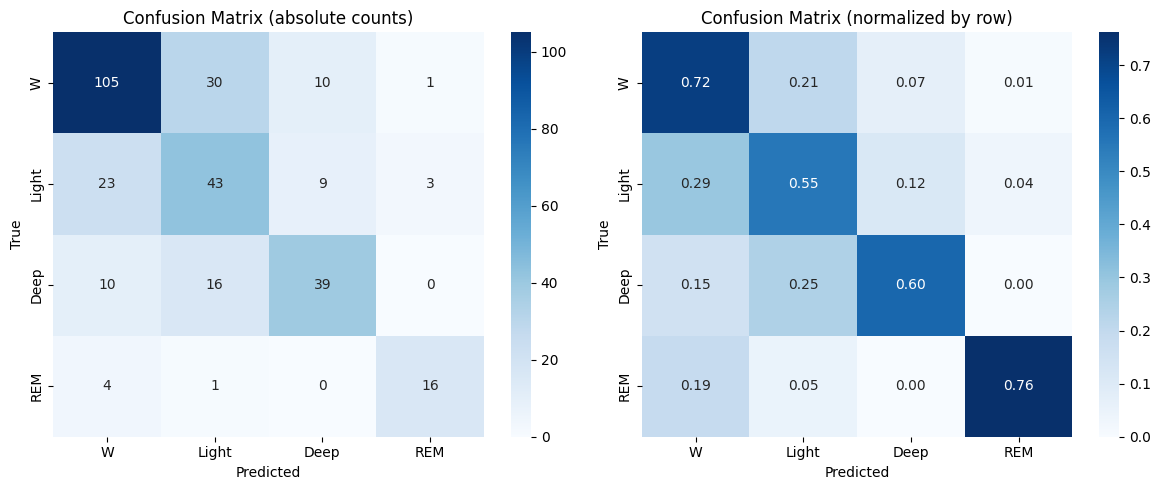

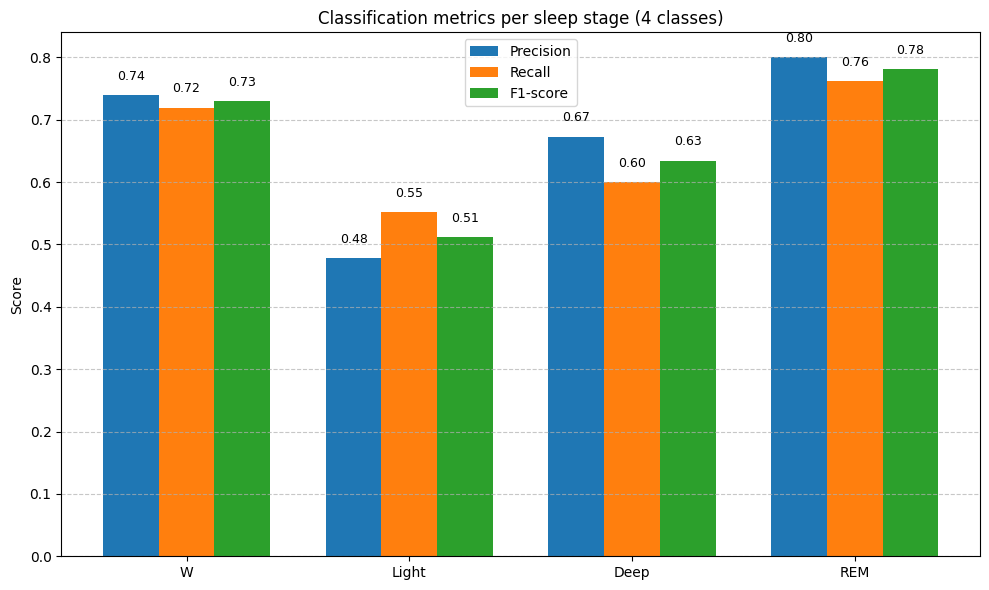

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


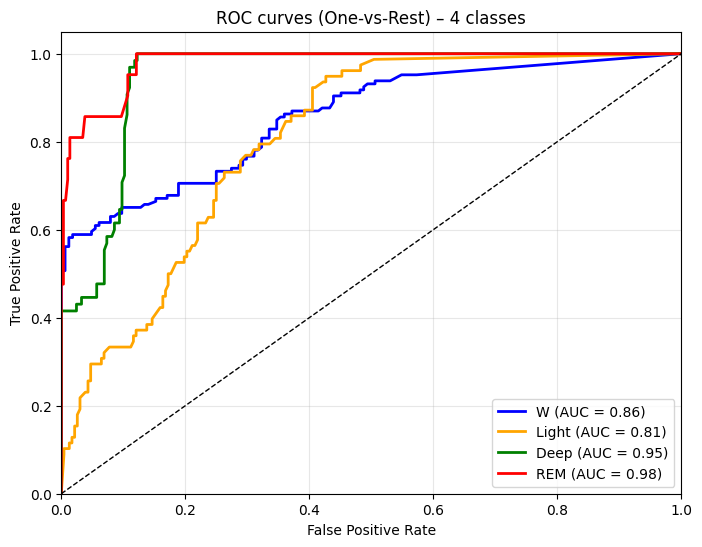

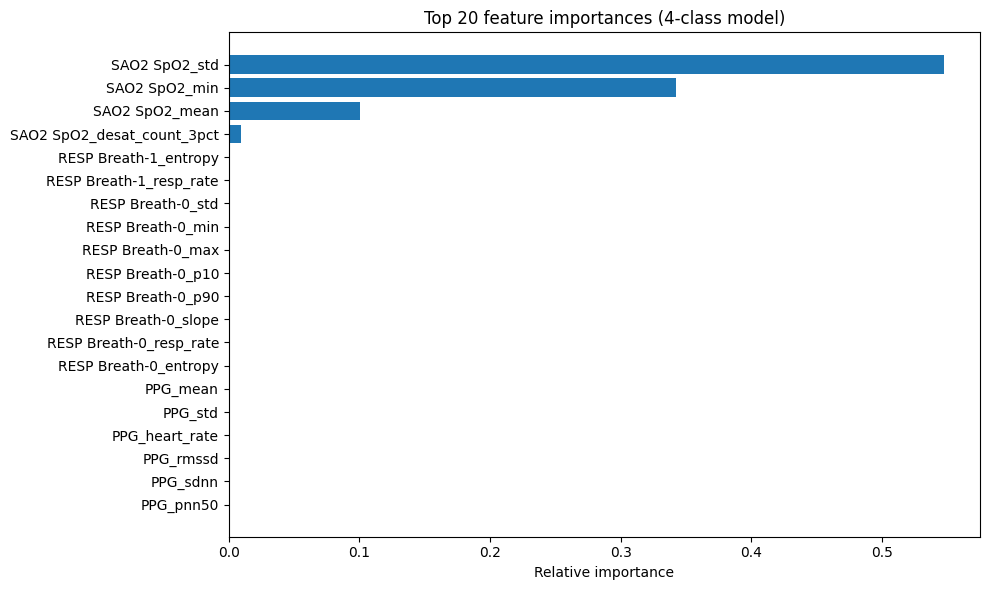

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
import numpy as np

# Названия классов для 4 стадий
class_names = ['W', 'Light', 'Deep', 'REM']
n_classes = len(class_names)

# 1. Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (absolute counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=class_names, yticklabels=class_names, cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix (normalized by row)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.tight_layout()
plt.show()

# 2. Precision, Recall, F1 по классам
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, precision, width, label='Precision')
ax.bar(x, recall, width, label='Recall')
ax.bar(x + width, f1, width, label='F1-score')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylabel('Score')
ax.set_title('Classification metrics per sleep stage (4 classes)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax.text(i - width, p + 0.02, f'{p:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(i, r + 0.02, f'{r:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width, f + 0.02, f'{f:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# 3. ROC-кривые (One-vs-Rest)
if hasattr(pipeline, 'predict_proba'):
    y_score = pipeline.predict_proba(X_test)
    y_test_bin = label_binarize(y_test, classes=range(n_classes))
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8,6))
    colors = ['blue', 'orange', 'green', 'red']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curves (One-vs-Rest) – 4 classes')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Модель не поддерживает predict_proba.")

# 4. Важность признаков (RandomForest)
if hasattr(pipeline.named_steps['classifier'], 'feature_importances_'):
    importances = pipeline.named_steps['classifier'].feature_importances_
    feature_names = X.columns
    indices = np.argsort(importances)[::-1][:20]
    plt.figure(figsize=(10, 6))
    plt.title('Top 20 feature importances (4-class model)')
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Модель не предоставляет важность признаков.")